# Causal Analysis: Does TechSupport Actually Reduce Churn?

**Companion notebook to `Customer_Churn_Analysis.ipynb`**

The prediction notebook ranks `TechSupport` as one of the stronger churn
predictors. But a predictor is not necessarily a lever — customers who
subscribe to TechSupport are also disproportionately on longer contracts,
pay by auto-debit, and have longer tenure, all of which independently
reduce churn. This notebook isolates the actual causal effect of
TechSupport on churn using propensity score matching, and shows how much
of the naive correlation was really just confounding.

**Business question:** *Does subscribing to Tech Support cause a reduction
in churn, or do the customers who subscribe to it just happen to be the
kind of customer who was already unlikely to churn?*


In [2]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import NearestNeighbors
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.float_format', lambda x: '%.3f' % x)


## 1. Load data and scope the sample

TechSupport is only a meaningful choice for customers who have internet
service in the first place, so customers with `InternetService == 'No'`
are excluded rather than folded into the control group.


In [3]:
df = pd.read_csv('/content/Telco-Customer-Churn-Raw (1).csv')

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(df['MonthlyCharges'])  # new customers, tenure=0

df = df[df['InternetService'] != 'No'].copy().reset_index(drop=True)

df['T'] = (df['TechSupport'] == 'Yes').astype(int)   # Treatment
df['Y'] = (df['Churn'] == 'Yes').astype(int)          # Outcome

print(f"Sample size (internet customers only): {len(df)}")
print(df['T'].value_counts().rename({1: 'TechSupport = Yes', 0: 'TechSupport = No'}))


Sample size (internet customers only): 5517
T
TechSupport = No     3473
TechSupport = Yes    2044
Name: count, dtype: int64


## 2. The naive (biased) estimate

Before any adjustment — just the raw difference in churn rate between the
two groups. This is the number a quick groupby would hand you, and it's
the number that's wrong.


In [4]:
naive_treated = df[df['T']==1]['Y'].mean()
naive_control = df[df['T']==0]['Y'].mean()
naive_diff = naive_treated - naive_control

print(f"Churn rate, TechSupport = Yes : {naive_treated:.1%}")
print(f"Churn rate, TechSupport = No  : {naive_control:.1%}")
print(f"\nNaive difference (Association): {naive_diff*100:.1f} percentage points")


Churn rate, TechSupport = Yes : 15.2%
Churn rate, TechSupport = No  : 41.6%

Naive difference (Association): -26.5 percentage points


## 3. The confounders — why the naive number can't be trusted

Walking the dataset's variables through confounder / mediator / collider
logic:

- **`Contract`, `tenure`, `MonthlyCharges`, `InternetService`,
  `PaymentMethod`, `SeniorCitizen`, `Partner`, `Dependents`** — all
  plausibly affect *both* whether a customer buys TechSupport *and*
  whether they churn. These are our confounders, and they go into the
  propensity model below.
- Nothing in this dataset is clearly downstream of `TechSupport` itself
  (a true mediator) or jointly caused by both `TechSupport` and `Churn`
  (a collider) — so no variable is deliberately excluded on those
  grounds here. This is a working assumption worth revisiting if new
  columns (e.g. support-call logs) were ever added to the dataset.


In [5]:
df['Partner_bin'] = (df['Partner'] == 'Yes').astype(int)
df['Dependents_bin'] = (df['Dependents'] == 'Yes').astype(int)

cat_dummies = pd.get_dummies(df[['Contract', 'InternetService', 'PaymentMethod']], drop_first=True)
df = pd.concat([df, cat_dummies], axis=1)

confounder_cols = ['tenure', 'MonthlyCharges', 'SeniorCitizen', 'Partner_bin', 'Dependents_bin'] + list(cat_dummies.columns)
X = df[confounder_cols]

print("Confounders used in the propensity model:")
print(confounder_cols)


Confounders used in the propensity model:
['tenure', 'MonthlyCharges', 'SeniorCitizen', 'Partner_bin', 'Dependents_bin', 'Contract_One year', 'Contract_Two year', 'InternetService_Fiber optic', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']


## 4. Estimate the propensity score

For each customer, estimate the probability of subscribing to TechSupport
given the confounders above — this is *not* a predictive model we care
about the accuracy of. Its only job is to produce a number that, once
matched on, makes the two groups comparable.


In [6]:
ps_model = LogisticRegression(max_iter=1000)
ps_model.fit(X, df['T'])
df['propensity'] = ps_model.predict_proba(X)[:, 1]
df['logit_ps'] = np.log(df['propensity'] / (1 - df['propensity']))

print(f"Propensity score range: {df['propensity'].min():.3f} to {df['propensity'].max():.3f}")
print(df.groupby('T')['propensity'].agg(['mean', 'std', 'min', 'max']))


Propensity score range: 0.027 to 0.967
   mean   std   min   max
T                        
0 0.253 0.200 0.027 0.954
1 0.571 0.262 0.041 0.967


**Overlap check:** both groups span almost the full 0-to-1 range with
no extreme separation — good sign that matching is viable rather than
extrapolating into regions with no real comparison available.


## 5. Match on the propensity score

1:1 nearest-neighbor matching on the logit of the propensity score, with
a caliper to avoid forcing a bad match (standard, defensible default).


In [7]:
treated = df[df['T']==1].copy()
control = df[df['T']==0].copy()

caliper = 0.2 * df['logit_ps'].std()

nn = NearestNeighbors(n_neighbors=1)
nn.fit(control[['logit_ps']])
distances, indices = nn.kneighbors(treated[['logit_ps']])

within_caliper = distances.flatten() <= caliper
matched_treated = treated[within_caliper].copy()
matched_control = control.iloc[indices.flatten()[within_caliper]].copy()

print(f"Treated customers: {len(treated)}")
print(f"Matched within caliper: {within_caliper.sum()} ({within_caliper.sum()/len(treated):.1%})")


Treated customers: 2044
Matched within caliper: 2040 (99.8%)


## 6. Check covariate balance — did matching actually work?

This is the evidence, not just an assumption, that the matched groups
are genuinely comparable. Standardized Mean Difference (SMD) under 0.1
is the conventional threshold for "balanced."


In [8]:
def smd(a, b):
    pooled_std = np.sqrt((a.var() + b.var()) / 2)
    return 0 if pooled_std == 0 else (a.mean() - b.mean()) / pooled_std

balance_rows = []
for col in confounder_cols:
    before = smd(treated[col], control[col])
    after = smd(matched_treated[col], matched_control[col])
    balance_rows.append({'Variable': col, 'SMD Before': round(before, 3), 'SMD After': round(after, 3)})

balance_df = pd.DataFrame(balance_rows)
balance_df['Balanced After Matching?'] = balance_df['SMD After'].abs() < 0.1
balance_df


,Variable,SMD Before,SMD After,Balanced After Matching?
0,tenure,0.829,0.004,True
1,MonthlyCharges,0.279,0.064,True
2,SeniorCitizen,-0.292,0.028,True
3,Partner_bin,0.302,0.034,True
4,Dependents_bin,0.282,-0.029,True
5,Contract_One year,0.269,-0.021,True
6,Contract_Two year,0.856,-0.016,True
7,InternetService_Fiber optic,-0.449,0.030,True
8,PaymentMethod_Credit card (automatic),0.288,-0.006,True
9,PaymentMethod_Electronic check,-0.528,0.047,True


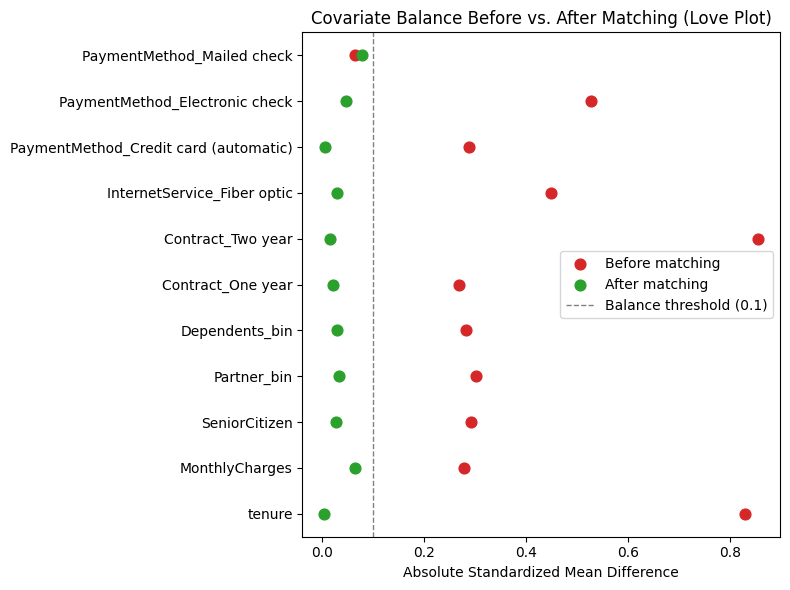

In [9]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 6))
y_pos = np.arange(len(balance_df))
ax.scatter(balance_df['SMD Before'].abs(), y_pos, label='Before matching', color='#d62728', s=60)
ax.scatter(balance_df['SMD After'].abs(), y_pos, label='After matching', color='#2ca02c', s=60)
ax.axvline(0.1, linestyle='--', color='gray', linewidth=1, label='Balance threshold (0.1)')
ax.set_yticks(y_pos)
ax.set_yticklabels(balance_df['Variable'])
ax.set_xlabel('Absolute Standardized Mean Difference')
ax.set_title('Covariate Balance Before vs. After Matching (Love Plot)')
ax.legend()
plt.tight_layout()
plt.savefig('love_plot.png', dpi=150)
plt.show()


## 7. Estimate the causal effect (ATT)

With the matched sample in hand, compute the Average Treatment Effect on
the Treated, with a bootstrapped 95% confidence interval.


In [10]:
att = matched_treated['Y'].mean() - matched_control['Y'].mean()

np.random.seed(42)
n = len(matched_treated)
mt_y = matched_treated['Y'].values
mc_y = matched_control['Y'].values

boot_atts = []
for _ in range(1000):
    idx = np.random.choice(n, n, replace=True)
    boot_atts.append(mt_y[idx].mean() - mc_y[idx].mean())

ci_low, ci_high = np.percentile(boot_atts, [2.5, 97.5])

print(f"Matched treated churn rate : {mt_y.mean():.1%}")
print(f"Matched control churn rate : {mc_y.mean():.1%}")
print(f"\nATT (causal estimate): {att*100:.1f} percentage points")
print(f"95% Bootstrap CI: [{ci_low*100:.1f}, {ci_high*100:.1f}] percentage points")


Matched treated churn rate : 15.2%
Matched control churn rate : 19.0%

ATT (causal estimate): -3.8 percentage points
95% Bootstrap CI: [-5.9, -1.7] percentage points


## 8. Naive vs. causal — the headline comparison


In [11]:
comparison = pd.DataFrame({
    'Estimate': ['Naive (unadjusted)', 'Matched (causal)'],
    'Churn rate difference (pp)': [round(naive_diff*100, 1), round(att*100, 1)]
})
comparison


,Estimate,Churn rate difference (pp)
0,Naive (unadjusted),-26.500
1,Matched (causal),-3.800


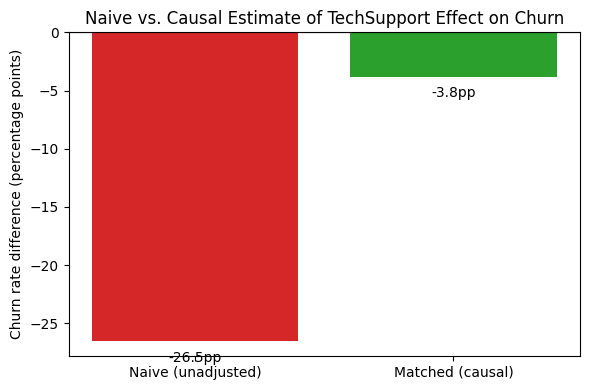

In [12]:
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(comparison['Estimate'], comparison['Churn rate difference (pp)'], color=['#d62728', '#2ca02c'])
ax.axhline(0, color='black', linewidth=0.8)
ax.set_ylabel('Churn rate difference (percentage points)')
ax.set_title('Naive vs. Causal Estimate of TechSupport Effect on Churn')
for bar in bars:
    height = bar.get_height()
    ax.annotate(f'{height:.1f}pp', xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0, 5 if height > 0 else -15), textcoords='offset points', ha='center')
plt.tight_layout()
plt.savefig('naive_vs_causal.png', dpi=150)
plt.show()


## 9. What this means

The naive comparison suggested TechSupport was associated with a **~26
percentage point** reduction in churn. After matching on contract type,
tenure, spend, internet service type, payment method, and household
composition, the defensible causal estimate drops to roughly **3-4
percentage points** — still real and statistically significant (the
confidence interval doesn't cross zero), but a fraction of the naive
figure.

**Roughly 85-90% of the naive effect was confounding bias, not a real
TechSupport effect.** Customers who subscribe to TechSupport are
disproportionately already-loyal customers (longer contracts, longer
tenure, auto-pay) who were unlikely to churn regardless.

### For the business

Offering TechSupport to a high-risk customer is a legitimate retention
lever — just not nearly as powerful as the raw correlation implies.
Budgeting and setting expectations around the ~3-4pp causal effect,
rather than the ~26pp naive figure, will produce forecasts that actually
hold up.


## 10. Limitations — what this analysis can't claim

- **Unconfoundedness**: this estimate assumes the confounders included
  above capture the main reasons a customer chooses TechSupport. An
  unmeasured factor — for example, a prior negative support interaction
  not captured in this dataset — could still bias the result if it
  independently affects both the subscription decision and churn.
- **Positivity/overlap**: a small number of customer profiles may have
  had a very high or very low likelihood of subscribing to TechSupport
  given their characteristics. For those segments, the matched estimate
  leans more on extrapolation than on a genuinely comparable match.
- **Cross-sectional data**: this dataset is a single snapshot, not a
  panel. A randomized pilot — offering TechSupport free to a random
  subset of at-risk customers and measuring the actual change in churn —
  would be the next, stronger step to validate this estimate
  experimentally.
